# Depth-edge analysis
Post-analysis for raw outputs from the YOLO + FoundationStereo pipeline.

Inputs expected in the selected run's `raw/` folder:
- depth.npy (float32 meters) or depth.exr (value in RED channel)
- edges.npy (uint8) or edges.png (uint8)

This notebook breaks the workflow into clear steps and displays results inline. It does not write any files to disk.

In [37]:
# Imports
import os, json
import sys
import numpy as np
import cv2
import imageio
import matplotlib.pyplot as plt
from pathlib import Path

# Add current directory to path to allow importing local modules
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

import corner_detection_lib as cdl

%matplotlib inline
plt.rcParams['figure.figsize'] = (10,6)

In [38]:
# Parameters
# Set raw_dir to the path of a run's raw/ folder. Use a raw string on Windows, e.g., r'C\\path\\to\\run\\raw'
# If left as None, the next cell will try to auto-detect a suitable raw/ folder.
seq = 11
path = os.getcwd()
raw_dir = rf'..\run_files\batch_outputs\seq{seq}\raw'  # e.g., r'C:\\Users\\1213123\\Documents\\Scripts\\FoundationStereo\\scripts\\unity_yolo\\output_3d_blocks\\your_run\\raw'

save_files = False  # whether to save output files (depth.npy, edges.npy, images, etc.)

buffer_px = 2
roi_margin_px = 2
method = 'canny'  # 'sobel' | 'laplacian' | 'canny'
edge_thresh = None  # absolute threshold for sobel/laplacian (meters/pixel); if None uses percentile
edge_sigma = 0.6  # for automatic thresholding if edge_thresh is None
max_edge_dist_px = 10  # maximum allowed distance from loaded edge to keep a depth edge
# Smoothing (pre-filter) to reduce noise before edge detection
# If True, a Gaussian blur will be applied (applies to depth for sobel/laplacian,
# and to the normalized image for Canny). Ensure ksize is odd and >=1.
smooth = True
smooth_ksize = 5  # must be odd (1,3,5,...); use 1 to disable smoothing effectually
smooth_sigma = 1.0  # sigma for Gaussian; 0 means let OpenCV compute from ksize

# Roots to search for runs if raw_dir is None or invalid (relative to this notebook location)
search_roots = [
    r'./output_3d_blocks',
    r'../output_3d_blocks',
    r'../../scripts/unity_yolo/output_3d_blocks',
    r'./scripts/unity_yolo/output_3d_blocks',
    r'../run_files/macro/output_3d_blocks',
    r'../run_files/macro/input_3d_blocks',
]

print('Initial raw_dir:', raw_dir)
print('buffer_px =', buffer_px)
print('roi_margin_px =', roi_margin_px)
print('method =', method)
print('edge_thresh =', edge_thresh, 'edge_sigma =', edge_sigma)
print('max_edge_dist_px =', max_edge_dist_px)
print('smooth =', smooth, 'smooth_ksize =', smooth_ksize, 'smooth_sigma =', smooth_sigma)

Initial raw_dir: ..\run_files\batch_outputs\seq11\raw
buffer_px = 2
roi_margin_px = 2
method = canny
edge_thresh = None edge_sigma = 0.6
max_edge_dist_px = 10
smooth = True smooth_ksize = 5 smooth_sigma = 1.0


In [39]:
# Step 0.5: Load camera intrinsics early (no depth scaling)
# This discovers Unity intrinsics (fx, fy, cx, cy) from a step0.frame_data.json if available.
# Intrinsics are used later to pixel-normalize depth gradients for edge detection.

# Optional: provide JSON path directly; otherwise we'll auto-discover similar to Step 8.6
early_step0_json_path = None  # e.g., r'C:\\path\\to\\step0.frame_data.json'

# Build candidate roots based on current notebook context
_early_candidates = []
if raw_dir is not None:
    _early_candidates += [raw_dir, os.path.dirname(raw_dir), os.path.dirname(os.path.dirname(raw_dir))]
_early_candidates += search_roots

fx, fy, cx, cy, json_path = cdl.find_camera_intrinsics(_early_candidates)

if fx is not None:
    globals()['fx'] = fx; globals()['fy'] = fy; globals()['cx'] = cx; globals()['cy'] = cy
    print(f'Early intrinsics: fx={fx:.3f}, fy={fy:.3f}, cx={cx:.3f}, cy={cy:.3f}')
    print('These intrinsics will be used to pixel-normalize Sobel depth gradients for edge detection.')
else:
    print('Early intrinsics: No RGBCamera capture found in JSON or JSON not found.')

Early intrinsics: fx=253.906, fy=253.906, cx=325.000, cy=200.000
These intrinsics will be used to pixel-normalize Sobel depth gradients for edge detection.


In [40]:
# Auto-detect and validate raw_dir
import time

if raw_dir is None or not os.path.isdir(raw_dir):
    print('\nTrying to auto-detect a raw/ folder...')
    detected_dir = cdl.auto_detect_raw_dir(search_roots)
    
    if detected_dir:
        raw_dir = detected_dir
        print('\nSelected raw_dir =', raw_dir)
    else:
        raise FileNotFoundError('Could not auto-detect a valid raw/ folder. Please set raw_dir to a specific path.')
else:
    print('Using provided raw_dir =', raw_dir)

# Quick peek at files inside raw_dir
try:
    names = os.listdir(raw_dir)
    print('\nraw_dir contents (first 20):')
    for n in names[:20]:
        print(' -', n)
except Exception as e:
    print('Warning: could not list raw_dir:', e)

Using provided raw_dir = ..\run_files\batch_outputs\seq11\raw

raw_dir contents (first 20):
 - depth.npy
 - disparity.npy
 - edges.npy
 - meta.json


In [41]:
# Helper functions for loading and preprocessing

import os, glob
import numpy as np
import cv2

try:
    import imageio
except ImportError:
    imageio = None

# Note: load_instance_metadata, filter_edges_by_top_instance, load_raw, buffer_edges, 
# compute_roi_from_mask, fill_invalid_with_median are now imported from corner_detection_lib as cdl

def depth_meter_to_pixel(depth_m: np.ndarray, fx: float, fy: float) -> np.ndarray:
    h, w = depth_m.shape[:2]
    y_idxs, x_idxs = np.indices((h, w), dtype=np.float32)
    x_norm = (x_idxs - (w / 2.0)) / fx
    y_norm = (y_idxs - (h / 2.0)) / fy
    depth_px = np.sqrt((depth_m * x_norm) ** 2 + (depth_m * y_norm) ** 2 + depth_m ** 2)
    return depth_px

def visualize_depth(depth: np.ndarray) -> np.ndarray:
    d = depth.copy()
    valid = np.isfinite(d) & (d > 0)
    if not valid.any():
        return np.zeros((*d.shape, 3), dtype=np.uint8)
    dmin = float(np.percentile(d[valid], 5))
    dmax = float(np.percentile(d[valid], 95))
    if dmax <= dmin:
        dmax = dmin + 1e-6
    d_clipped = np.clip(d, dmin, dmax)
    d_norm = (d_clipped - dmin) / (dmax - dmin)
    d_norm[~valid] = 0
    img_u8 = (np.clip(d_norm, 0, 1) * 255).astype(np.uint8)
    color = cv2.applyColorMap(img_u8, cv2.COLORMAP_TURBO)
    color[~valid] = 0
    return color

Converting depth from metric (m) to pixel units using fx, fy
Depth shape: (400, 650) dtype: float32 min: 1.0 max: 999.79315
Edges shape: (400, 650) dtype: uint8 nonzero: 578


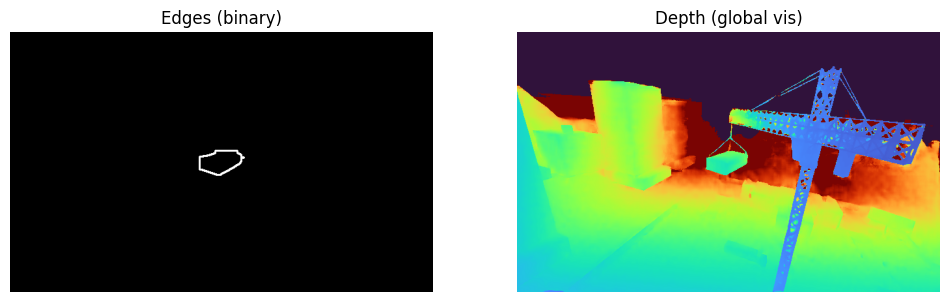

In [42]:
# Step 1: Load raw depth and edges, inspect (no unit scaling)
# Set filter_top_instance=True to only use the instance edge with highest confidence
depth, edges_bin = cdl.load_raw(raw_dir, filter_top_instance=True)

# Optional: metric->pixel conversion if intrinsics available (fx, fy from Step 0.5)
if 'fx' in globals() and 'fy' in globals() and np.isfinite(globals()['fx']) and np.isfinite(globals()['fy']):
    print('Converting depth from metric (m) to pixel units using fx, fy')
    depth_factored = depth_meter_to_pixel(depth, globals()['fx'], globals()['fy'])
else:
    depth_factored = depth

print('Depth shape:', depth.shape, 'dtype:', depth.dtype, 'min:', np.nanmin(depth), 'max:', np.nanmax(depth))
print('Edges shape:', edges_bin.shape, 'dtype:', edges_bin.dtype, 'nonzero:', int((edges_bin>0).sum()))

fig, axs = plt.subplots(1, 2, figsize=(12,5))
axs[0].imshow(edges_bin, cmap='gray'); axs[0].set_title('Edges (binary)'); axs[0].axis('off')
# Quick depth visualization (global)
valid = np.isfinite(depth) & (depth > 0)
if valid.any():
    dmin = float(np.percentile(depth[valid], 5)); dmax = float(np.percentile(depth[valid], 95))
    d_vis = visualize_depth(depth)
    axs[1].imshow(d_vis[..., ::-1]); axs[1].set_title('Depth (global vis)'); axs[1].axis('off')
else:
    axs[1].imshow(np.zeros((*depth.shape,3), dtype=np.uint8)); axs[1].set_title('Depth (no valid)'); axs[1].axis('off')
plt.show()

In [43]:
# Step 2: Optionally flatten far depths (depth > T := flatten_far_m)
#if flatten_far_m is not None:
#    T = float(flatten_far_m)
#    far_mask = np.isfinite(depth) & (depth > T)
#    changed = int(far_mask.sum())
#    if changed > 0:
#        depth = depth.copy(); depth[far_mask] = T
#    print(f'Flattened far depths above {T} m. Pixels changed:', changed)
#else:
#    print('No flattening applied.')

Buffered edges nonzero: 1402


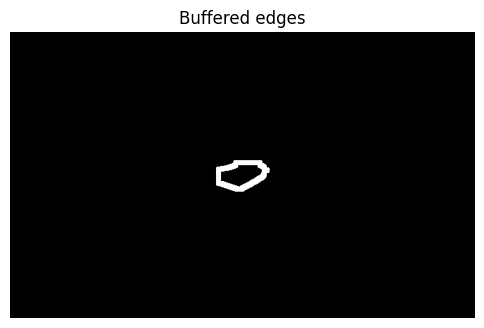

In [44]:
# Step 3: Buffer edges and visualize
buf = cdl.buffer_edges(edges_bin, buffer_px)
print('Buffered edges nonzero:', int((buf>0).sum()))

fig, ax = plt.subplots(1, 1, figsize=(6,5))
ax.imshow(buf, cmap='gray'); ax.set_title('Buffered edges'); ax.axis('off')
plt.show()

ROI: (286, 178, 364, 225)


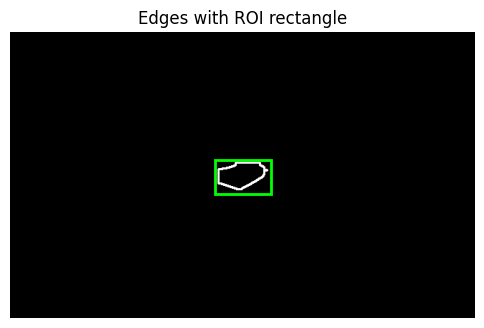

In [45]:
# Step 4: ROI from buffered mask
roi = cdl.compute_roi_from_mask(buf, roi_margin_px)
print('ROI:', roi)

# Visualize ROI rectangle on edges for context
fig, ax = plt.subplots(1, 1, figsize=(6,5))
ax.imshow(edges_bin, cmap='gray')
if roi is not None:
    x1, y1, x2, y2 = roi
    import matplotlib.patches as patches
    rect = patches.Rectangle((x1, y1), (x2-x1+1), (y2-y1+1), linewidth=2, edgecolor='lime', facecolor='none')
    ax.add_patch(rect)
    ax.set_title('Edges with ROI rectangle')
else:
    ax.set_title('Edges (no ROI found)')
ax.axis('off')
plt.show()

depth_roi shape: (48, 79) min: 43.037643 max: 322.41837


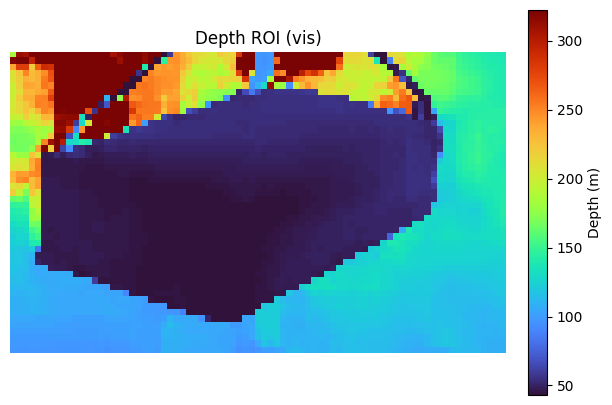

In [46]:
# Step 5: Clip depth to ROI, filter outliers (5-95%), and visualize
if roi is not None:
    x1, y1, x2, y2 = roi
    depth_roi_raw = depth[y1:y2+1, x1:x2+1]
    
    # Filter outliers: clip to 5-95 percentile of valid pixels
    depth_roi = depth_roi_raw.copy()
    valid_mask = (depth_roi > 0) & np.isfinite(depth_roi)
    
    dmin, dmax = 0.0, 1.0 # Default
    if valid_mask.any():
        valid_pixels = depth_roi[valid_mask]
        dmin = float(np.percentile(valid_pixels, 5))
        dmax = float(np.percentile(valid_pixels, 95))
        depth_roi[valid_mask] = np.clip(depth_roi[valid_mask], dmin, dmax)
        
    print('depth_roi shape:', depth_roi.shape, 'min:', np.nanmin(depth_roi), 'max:', np.nanmax(depth_roi))
    depth_roi_vis = visualize_depth(depth_roi)
    
    fig, ax = plt.subplots(figsize=(7,5))
    ax.imshow(depth_roi_vis[..., ::-1])
    ax.set_title('Depth ROI (vis)')
    ax.axis('off')
    
    # Add colorbar
    try:
        from matplotlib.colors import Normalize
        from matplotlib.cm import ScalarMappable
        if dmax <= dmin: dmax = dmin + 1e-6
        norm = Normalize(vmin=dmin, vmax=dmax)
        sm = ScalarMappable(cmap='turbo', norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Depth (m)')
    except Exception as e:
        print('Failed to add colorbar:', e)
        
    plt.show()
else:
    print('No ROI – skipping depth ROI step.')

# Step 5.5: Morphological smoothing (erode → dilate)
We perform a small morphological opening with OpenCV to smooth jagged edges.
- Visualization: apply erode→dilate to `depth_roi_vis` to show a cleaner edge.
- Depth (for Step 6): also compute `depth_roi_smooth` by eroding then dilating the metric `depth_roi` (after filling invalid values), so Step 6 can use the smoothed depth when detecting edges.

Removed 11 outlier pixels from smoothed depth using 2-sigma clipping.


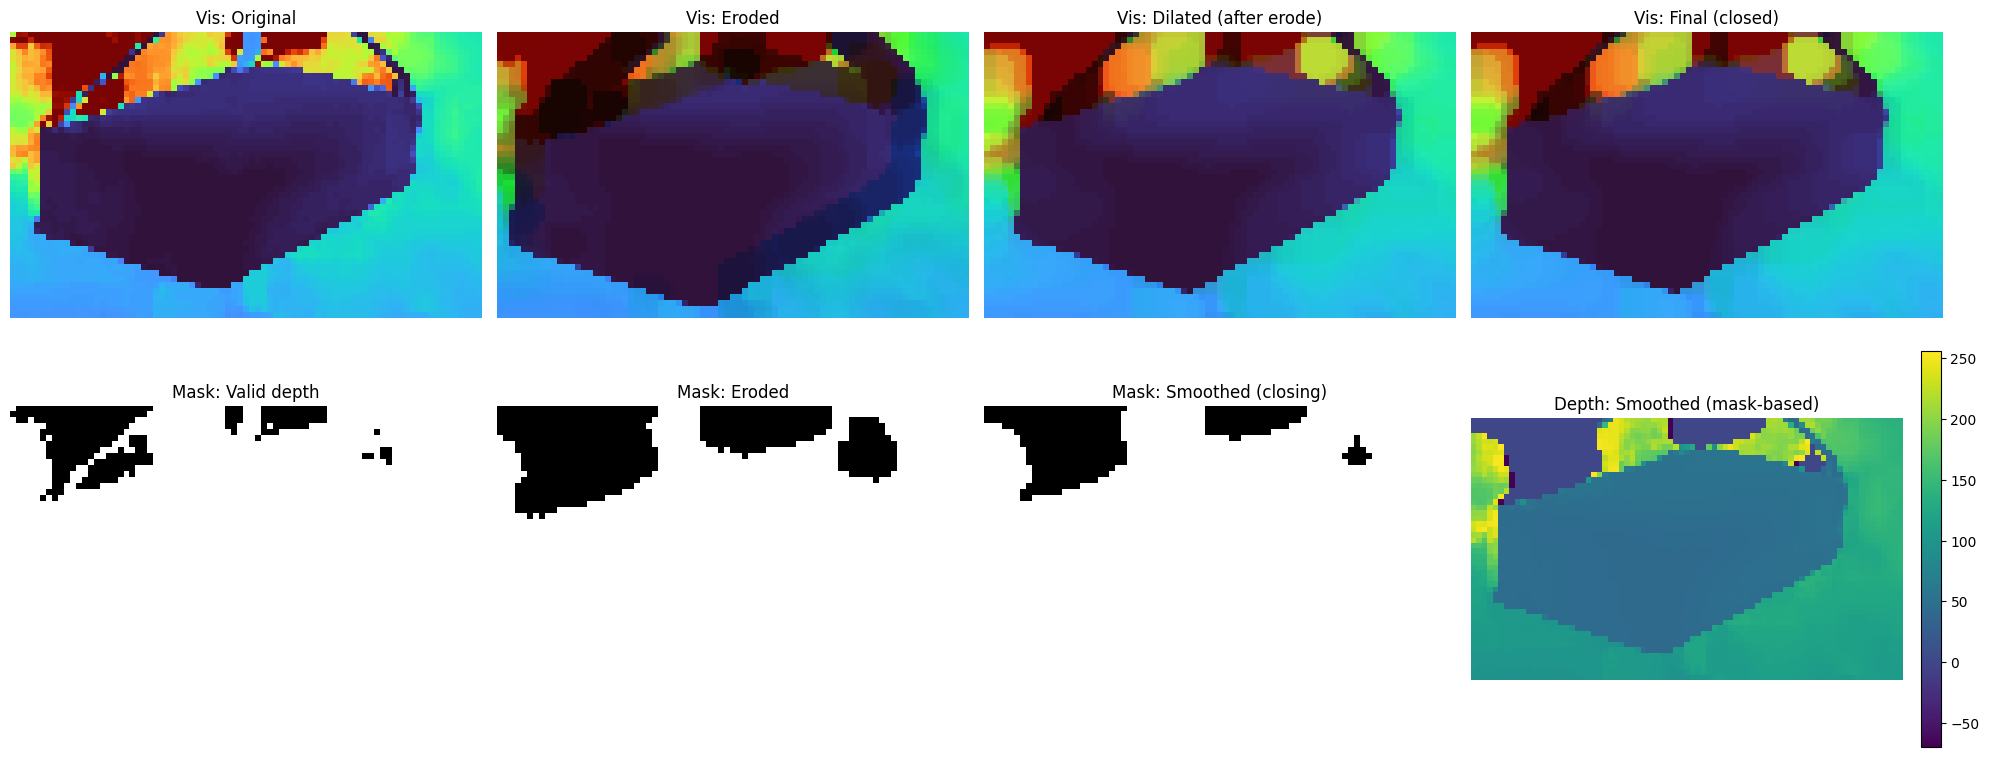

In [ ]:
# Step 5.5: Morphological smoothing of ROI visualization and depth (closing operation)
import cv2
import numpy as np
import matplotlib.pyplot as plt

if roi is not None:
    # Use library function for smoothing
    depth_roi_smooth, valid_mask, mask_eroded, mask_smooth = cdl.smooth_depth_roi(depth_roi, buffer_px)
    
    # --- Visualization smoothing (non-destructive) for display only
    k = max(1, int(round(buffer_px / 4))) if 'buffer_px' in globals() else 1
    ks = 5 * k + 1
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ks, ks))
    roi_eroded = cv2.erode(depth_roi_vis, kernel, iterations=1)
    roi_dilated = cv2.dilate(roi_eroded, kernel, iterations=1)
    depth_roi_vis_smooth = roi_dilated

    # Show morphological smoothing steps
    fig, axs = plt.subplots(2, 4, figsize=(20, 8))
    
    # Row 1: Visualization (BGR images)
    axs[0, 0].imshow(depth_roi_vis[..., ::-1]); axs[0, 0].set_title('Vis: Original'); axs[0, 0].axis('off')
    axs[0, 1].imshow(roi_eroded[..., ::-1]); axs[0, 1].set_title('Vis: Eroded'); axs[0, 1].axis('off')
    axs[0, 2].imshow(roi_dilated[..., ::-1]); axs[0, 2].set_title('Vis: Dilated (after erode)'); axs[0, 2].axis('off')
    axs[0, 3].imshow(depth_roi_vis_smooth[..., ::-1]); axs[0, 3].set_title('Vis: Final (closed)'); axs[0, 3].axis('off')
    
    # Row 2: Mask-based depth smoothing
    try:
        # Show valid mask and its smoothing
        axs[1, 0].imshow(valid_mask, cmap='gray')
        axs[1, 0].set_title('Mask: Valid depth')
        axs[1, 0].axis('off')
        
        axs[1, 1].imshow(mask_eroded, cmap='gray')
        axs[1, 1].set_title('Mask: Eroded')
        axs[1, 1].axis('off')
        
        axs[1, 2].imshow(mask_smooth, cmap='gray')
        axs[1, 2].set_title('Mask: Smoothed (closing)')
        axs[1, 2].axis('off')
        
        # Show final smoothed depth
        im2 = axs[1, 3].imshow(depth_roi_smooth, cmap='viridis')
        axs[1, 3].set_title('Depth: Smoothed (mask-based)')
        axs[1, 3].axis('off')
        plt.colorbar(im2, ax=axs[1, 3], fraction=0.046, pad=0.04)
    except Exception as e:
        print(f'Visualization error: {e}')
    
    plt.tight_layout()
    plt.show()
else:
    print('No ROI – skipping Step 5.5 (morphological smoothing).')

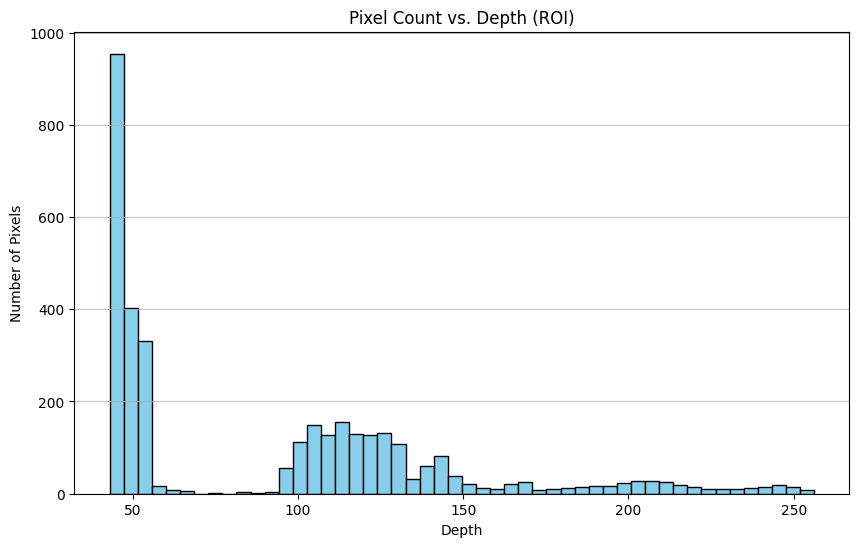

In [48]:
# Step 5.6: Bar chart plot of pixel count vs depth
if roi is not None:
    # Choose the depth map to analyze
    depth_to_plot = depth_roi_smooth
    
    # Flatten and filter valid depth values (ignore 0 and NaN)
    valid_depths = depth_to_plot.flatten()
    valid_depths = valid_depths[(valid_depths > 0) & np.isfinite(valid_depths)]
    
    if len(valid_depths) > 0:
        plt.figure(figsize=(10, 6))
        # Use a histogram to show pixel counts vs depth
        # 'bins' determines the resolution of the depth bars
        plt.hist(valid_depths, bins=50, color='skyblue', edgecolor='black')
        plt.title('Pixel Count vs. Depth (ROI)')
        plt.xlabel('Depth')
        plt.ylabel('Number of Pixels')
        plt.grid(axis='y', alpha=0.75)
        plt.show()
    else:
        print("No valid depth values to plot.")
else:
    print("No ROI - skipping Step 5.6 plot.")

Using smoothed depth (depth_roi_smooth) for edge detection.
Gradient shape: (48, 79) min: 0.0 max: 929.540283203125
Depth-edges nonzero: 297


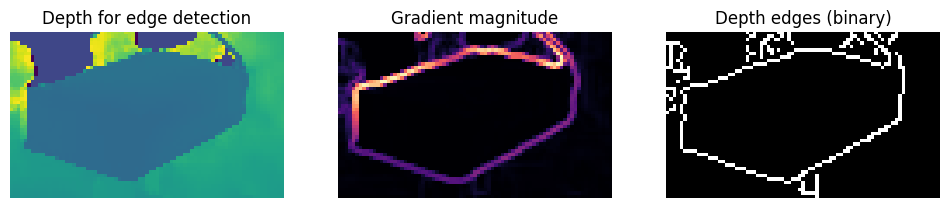

In [49]:
# Step 6: Detect depth edges inside ROI and visualize
if roi is not None:
    # Prefer smoothed depth if available from Step 5.5
    depth_for_edges = depth_roi_smooth
    if 'depth_roi_smooth' in globals():
        print('Using smoothed depth (depth_roi_smooth) for edge detection.')
    else:
        print('Using original depth_roi for edge detection (no smoothed depth available).')
    
    grad, depth_edges = cdl.detect_depth_edges(depth_for_edges, method, edge_thresh, edge_sigma, False)
    print('Gradient shape:', grad.shape, 'min:', float(np.min(grad)), 'max:', float(np.max(grad)))
    print('Depth-edges nonzero:', int((depth_edges>0).sum()))
    
    fig, axs = plt.subplots(1, 3, figsize=(12,5))
    axs[0].imshow(depth_for_edges, cmap='viridis'); axs[0].set_title('Depth for edge detection'); axs[0].axis('off')
    axs[1].imshow(grad, cmap='magma'); axs[1].set_title('Gradient magnitude'); axs[1].axis('off')
    axs[2].imshow(depth_edges, cmap='gray'); axs[2].set_title('Depth edges (binary)'); axs[2].axis('off')
    plt.show()
else:
    print('No ROI – skipping edge detection step.')

Filtered depth edges with max distance 10.0px: kept 292 / 297


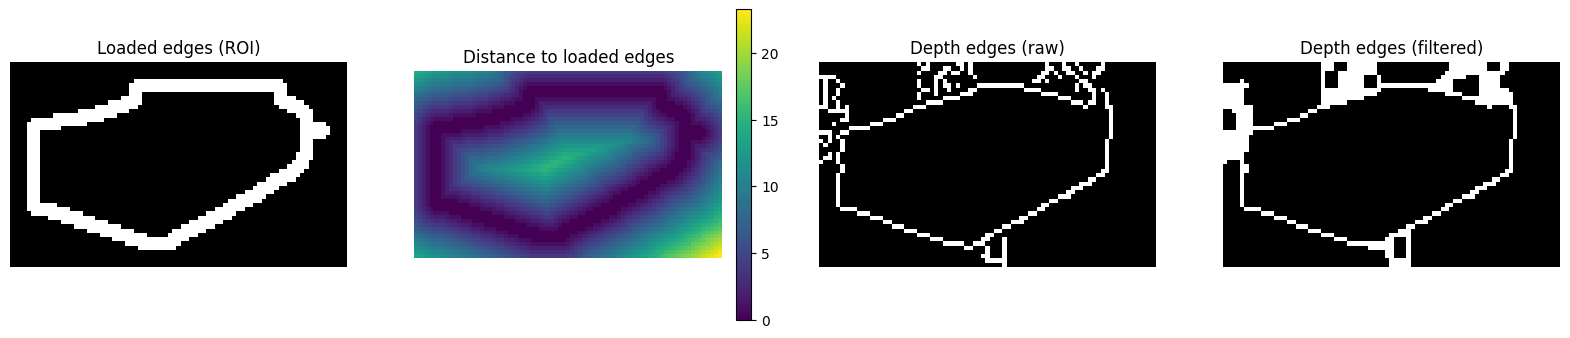

In [ ]:
# Step 6.5: Filter depth edges by proximity to loaded edges (within ROI)
if roi is not None:
    # Extract loaded edges within ROI
    loaded_edges_roi = (edges_bin[y1:y2+1, x1:x2+1] > 0).astype(np.uint8)
    
    # Use library function for filtering
    max_d = float(max_edge_dist_px)
    depth_edges_filtered, dt = cdl.filter_depth_edges(depth_edges, loaded_edges_roi, max_d, buffer_px)
    
    kept = int((depth_edges_filtered > 0).sum())
    total = int((depth_edges > 0).sum())
    print(f'Filtered depth edges with max distance {max_d}px: kept {kept} / {total}')

    # Visualize comparison
    fig, axs = plt.subplots(1, 4, figsize=(20,5))
    axs[0].imshow(loaded_edges_roi, cmap='gray'); axs[0].set_title('Loaded edges (ROI)'); axs[0].axis('off')
    im1 = axs[1].imshow(dt, cmap='viridis'); axs[1].set_title('Distance to loaded edges'); axs[1].axis('off')
    plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)
    axs[2].imshow(depth_edges, cmap='gray'); axs[2].set_title('Depth edges (raw)'); axs[2].axis('off')
    axs[3].imshow(depth_edges_filtered, cmap='gray'); axs[3].set_title('Depth edges (filtered)'); axs[3].axis('off')
    plt.show()
else:
    print('No ROI – skipping proximity filtering step.')

Finding closed loop using library function...

Final best loop: area = 2038.5 px, perimeter = 244.9 px, vertices = 33


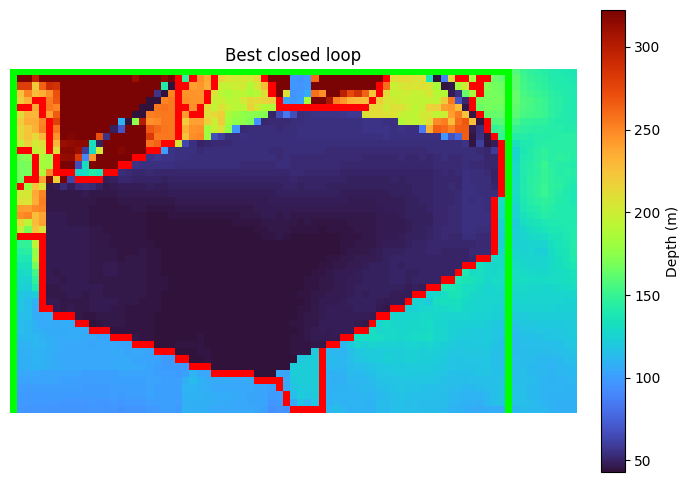

In [51]:
# Step 7: Find closed loops with iterative morphological closing
if roi is not None:
    print('Finding closed loop using library function...')
    best_loop = cdl.find_closed_loop(depth_edges_filtered, depth_roi, buffer_px)
    
    # Visualize final result
    vis = depth_roi_vis.copy()
    if best_loop is not None:
        # Draw best loop in red
        cv2.drawContours(vis, [best_loop], -1, (0, 0, 255), 1)
        
        # Draw bounding box in green for reference
        x, y, w, h = cv2.boundingRect(best_loop)
        cv2.rectangle(vis, (x, y), (x+w, y+h), (0, 255, 0), 1)
        
        print(f'\nFinal best loop: area = {float(cv2.contourArea(best_loop)):.1f} px, perimeter = {float(cv2.arcLength(best_loop, True)):.1f} px, vertices = {len(best_loop)}')
    else:
        print('\nNo suitable closed loop found.')
    
    # Plot with depth legend (colorbar)
    fig = plt.figure(figsize=(8,6))
    ax = plt.gca()
    ax.imshow(vis[..., ::-1])
    if best_loop is not None:
        ax.set_title(f'Best closed loop')
    else:
        ax.set_title('No suitable loop found')
    ax.axis('off')
    
    # Add colorbar representing depth range
    try:
        from matplotlib.colors import Normalize
        from matplotlib.cm import ScalarMappable
        valid = np.isfinite(depth_roi) & (depth_roi > 0)
        if valid.any():
            dmin = float(np.percentile(depth_roi[valid], 5))
            dmax = float(np.percentile(depth_roi[valid], 95))
            if dmax <= dmin:
                dmax = dmin + 1e-6
            norm = Normalize(vmin=dmin, vmax=dmax)
            sm = ScalarMappable(cmap='turbo', norm=norm)
            sm.set_array([])
            cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
            cbar.set_label('Depth (m)')
        else:
            print('No valid depth values for colorbar.')
    except Exception as e:
        print('Failed to add depth colorbar:', e)
    
    plt.show()
else:
    print('No ROI – skipping closed loop detection step.')

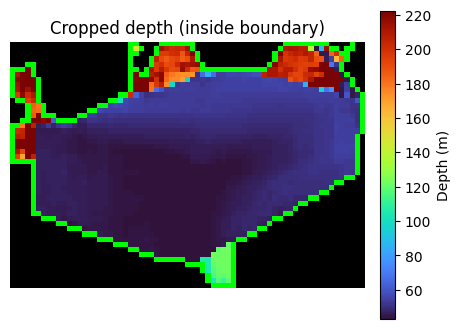

Prepared 2155 pixel-space points (x_px, y_px, z_m).
Export of 3D point data (PLY/NPZ) is deferred to Step 8.7 after unit conversion to meters.


In [52]:
# Step 8: Extract depth data within the selected boundary, visualize (ROI + cropped) and save for downstream use
import time

if roi is not None and 'best_loop' in globals() and best_loop is not None:
    # Determine destination directory (prefer raw_dir if available)
    dest_dir = raw_dir if (raw_dir is not None and os.path.isdir(raw_dir)) else os.getcwd()

    # best_loop is a contour in ROI coordinates
    poly = best_loop.reshape(-1, 2).astype(np.int32)

    # Build mask for the polygon (1 inside, 0 outside)
    mask = np.zeros(depth_roi.shape[:2], dtype=np.uint8)
    cv2.fillPoly(mask, [poly], 1)

    # Extract depth values inside polygon
    depth_inside = depth_roi.copy()
    # Option: set outside to 0 or np.nan; here we keep 0 for ease of saving/consumption
    depth_outside_zero = depth_inside.copy()
    depth_outside_zero[mask == 0] = 0

    # Compute bounding box of polygon and crop for compact storage
    bx, by, bw, bh = cv2.boundingRect(poly)
    if bw <= 0 or bh <= 0:
        print('Invalid bbox; nothing to crop')
    else:
        cropped_depth = depth_outside_zero[by:by+bh, bx:bx+bw]
        cropped_mask = mask[by:by+bh, bx:bx+bw]

        try:
            # --- Visualization: cropped depth (only bbox region) with polygon drawn in local coords
            # Prepare cropped visualization using visualize_depth (set outside to nan so it's blank)
            tmp = cropped_depth.copy().astype(np.float32)
            tmp[cropped_mask == 0] = np.nan
            cropped_vis = visualize_depth(tmp)

            # Draw polygon shifted to local (cropped) coordinates
            poly_local = (poly - np.array([bx, by])).reshape(-1, 2).astype(np.int32)
            cropped_vis_draw = cropped_vis.copy()
            # If polygon has at least 2 points draw polylines, else draw contour
            if poly_local.shape[0] >= 2:
                cv2.polylines(cropped_vis_draw, [poly_local], True, (0, 255, 0), thickness=1)

            # Plot with colorbar
            fig, ax = plt.subplots(figsize=(5, 4))
            ax.imshow(cropped_vis_draw[..., ::-1])
            ax.set_title('Cropped depth (inside boundary)')
            ax.axis('off')

            # Add colorbar
            try:
                from matplotlib.colors import Normalize
                from matplotlib.cm import ScalarMappable
                
                # Compute range from the cropped depth (ignoring 0/nan)
                valid_d = cropped_depth[cropped_depth > 0]
                if valid_d.size > 0:
                    dmin = float(np.percentile(valid_d, 5))
                    dmax = float(np.percentile(valid_d, 95))
                    if dmax <= dmin:
                        dmax = dmin + 1e-6
                    
                    norm = Normalize(vmin=dmin, vmax=dmax)
                    sm = ScalarMappable(cmap='turbo', norm=norm)
                    sm.set_array([])
                    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
                    cbar.set_label('Depth (m)')
            except Exception as e:
                print('Failed to add colorbar:', e)

            plt.show()

        except Exception as e:
            print('Visualization failed:', e)

        if save_files:

            # Compose export filename for ROI arrays (NOT the 3D points)
            ts = time.strftime('%Y%m%d_%H%M%S', time.localtime())
            fname = os.path.join(dest_dir, f'depth_boundary.npz')

            # Save compressed .npz containing full ROI depth, mask, polygon, bbox and cropped arrays
            np.savez_compressed(
                fname,
                depth_roi=depth_roi,
                mask=mask,
                polygon=poly,
                bbox=(int(bx), int(by), int(bw), int(bh)),
                cropped_depth=cropped_depth,
                cropped_mask=cropped_mask,
            )

            print('Saved ROI arrays to', fname)
            print('Saved arrays: depth_roi (full ROI), mask (ROI-size binary mask), polygon (Nx2 int coords), bbox, cropped_depth, cropped_mask')

        # --- Build point list in image pixel space (to be converted to meters in Step 8.6)
        pts = []
        # cropped_mask and cropped_depth are local (bbox-local). We'll compute global image coords for X,Y so the cloud is in image pixel-space + depth as Z.
        rows, cols = np.where(cropped_mask > 0)
        for r, c in zip(rows, cols):
            z = float(cropped_depth[r, c])
            # ignore invalid depth
            if not np.isfinite(z) or z <= 0:
                continue
            # global image coordinates (x = column, y = row) relative to the full image
            gx = float(x1 + bx + c)
            gy = float(y1 + by + r)
            pts.append((gx, gy, z))

        print(f'Prepared {len(pts)} pixel-space points (x_px, y_px, z_m).')
        print('Export of 3D point data (PLY/NPZ) is deferred to Step 8.7 after unit conversion to meters.')
else:
    print('No ROI or no best_loop found — nothing to save or visualize.')

Using step0 JSON: c:\Users\tedbe\.vscode\scripts\FoundationStereo\scripts\run_files\batch_inputs\seq11\step0.frame_data.json
Intrinsics (pixels): fx=253.906, fy=253.906, cx=325.000, cy=200.000
Filtering 437 Z-outliers (> 82.56 m)
Centroid (camera-space meters): [-0.44425063744959564, 0.01768576660594564, 47.76048090960288]
Point cloud size (after filtering): (1718, 3)


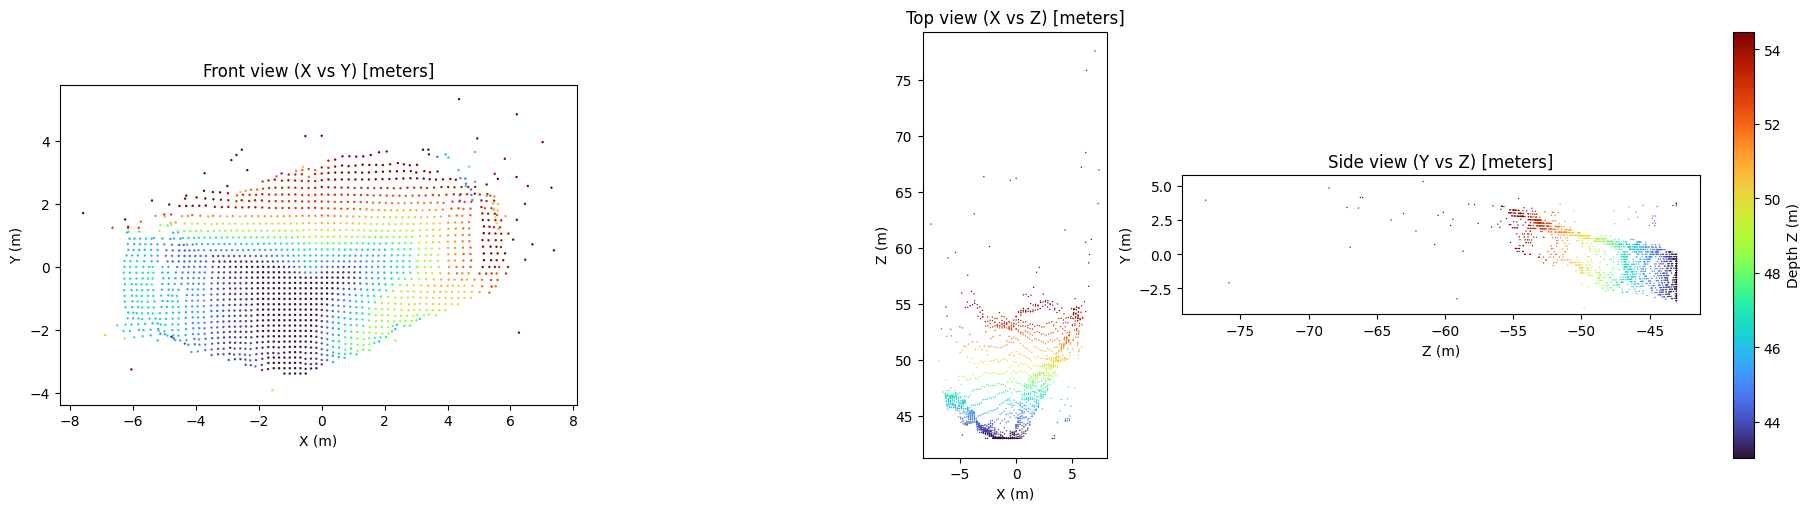

In [53]:
# Step 8.6: Convert pixel (x,y) to meters using camera intrinsics from step0.frame_data.json and re-plot multi-view
# This computes camera-space metric coordinates (Xc, Yc, Zc) in meters using pinhole projection.
# If a suitable step0.frame_data.json cannot be located, the cell will fall back and print guidance.

# Optional: set this manually if auto-discovery fails
step0_json_path = None  # e.g., r'C:\\path\\to\\step0.frame_data.json'

import os, json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# Helper to discover a step0.frame_data.json if not provided
def find_step0_json(start_dirs):
    names = ['step0.frame_data.json', 'frame_data.json']
    for root in start_dirs:
        try:
            root_abs = os.path.abspath(root)
            if not os.path.isdir(root_abs):
                continue
            for dirpath, dirnames, filenames in os.walk(root_abs):
                for n in filenames:
                    if n.lower() in names:
                        return os.path.join(dirpath, n)
        except Exception:
            pass
    return None

# Build candidate roots based on current notebook context
candidate_roots = []
if 'raw_dir' in globals() and raw_dir is not None:
    input_dir = raw_dir.replace("output","input")
    candidate_roots += [input_dir, os.path.dirname(input_dir), os.path.dirname(os.path.dirname(input_dir))]
# Common repo locations
candidate_roots += [
    '.',
    './image_sample',
    './scripts/post_analysis/run_files/input_3d_blocks',
    './scripts/run_files/input_3d_blocks',
]

# Resolve JSON path
if step0_json_path is None:
    step0_json_path = find_step0_json(candidate_roots)

if not step0_json_path or not os.path.isfile(step0_json_path):
    print('Could not locate step0.frame_data.json automatically. Set step0_json_path to the file path and re-run this cell.')
else:
    print('Using step0 JSON:', step0_json_path)

    # Load camera data (take the first RGBCamera capture by default)
    with open(step0_json_path, 'r') as f:
        data = json.load(f)

    captures = data.get('captures', [])
    cam = None
    for c in captures:
        if c.get('@type', '').endswith('RGBCamera'):
            cam = c
            break

    if cam is None:
        print('No RGBCamera capture found in JSON.')
    else:
        dim = cam.get('dimension', None)
        proj = cam.get('matrix', None)
        if (not dim) or (not proj) or len(dim) < 2 or len(proj) < 9:
            print('JSON missing expected fields: dimension or matrix. Cannot compute intrinsics.')
        else:
            # Width/height in pixels (as floats in JSON)
            width = float(dim[0])
            height = float(dim[1])
            # Unity/GL-style projection (3x3 block):
            # P[0,0] = 2*fx/width, P[1,1] = 2*fy/height when principal point is centered and skew=0
            P00 = float(proj[0])
            P11 = float(proj[4])
            fx = P00 * width / 2.0
            fy = P11 * height / 2.0
            # Assume centered principal point if not provided
            cx = width / 2.0
            cy = height / 2.0
            print(f'Intrinsics (pixels): fx={fx:.3f}, fy={fy:.3f}, cx={cx:.3f}, cy={cy:.3f}')

            # Ensure we have a point cloud from Step 8
            try:
                has_pts = ('pts' in globals()) and isinstance(pts, (list, tuple)) and len(pts) > 0
            except Exception:
                has_pts = False

            if not has_pts:
                print('No point cloud (`pts`) found. Run Step 8 first to generate the masked point cloud.')
            else:
                Ppx = np.array(pts, dtype=float)  # (N,3) => (u,v,Z)
                if Ppx.ndim != 2 or Ppx.shape[1] != 3:
                    print('Unexpected `pts` shape:', Ppx.shape)
                else:
                    u = Ppx[:, 0]
                    v = Ppx[:, 1]
                    Z = Ppx[:, 2]  # meters (depth)
                    # Filter invalid depths
                    valid = np.isfinite(Z) & (Z > 0)

                    # --- Filter Z outliers (e.g. > 3*IQR) ---
                    if valid.any():
                        q1 = np.percentile(Z[valid], 25)
                        q3 = np.percentile(Z[valid], 75)
                        iqr = q3 - q1
                        upper_fence = q3 + 3.0 * iqr
                        # Also filter extremely large values just in case
                        if upper_fence > 0:
                            valid_outlier = (Z <= upper_fence)
                            n_out = np.sum(valid & ~valid_outlier)
                            if n_out > 0:
                                print(f'Filtering {n_out} Z-outliers (> {upper_fence:.2f} m)')
                                valid = valid & valid_outlier

                    u = u[valid]; v = v[valid]; Z = Z[valid]

                    # Pinhole: Xc = (u - cx)/fx * Z, Yc = (v - cy)/fy * Z, Zc = Z
                    Xc = (u - cx) / fx * Z
                    Yc = (v - cy) / fy * Z
                    Zc = Z

                    Pc = np.stack([Xc, Yc, Zc], axis=1)
                    centroid = Pc.mean(axis=0) if Pc.size else np.array([np.nan, np.nan, np.nan])
                    print('Centroid (camera-space meters):', centroid.tolist())
                    print('Point cloud size (after filtering):', Pc.shape)

                    # Depth color mapping via robust range
                    z5 = float(np.percentile(Zc, 5)) if Zc.size else 0.0
                    z95 = float(np.percentile(Zc, 95)) if Zc.size else 1.0
                    if z95 <= z5:
                        z95 = z5 + 1e-6
                    norm = Normalize(vmin=z5, vmax=z95)
                    sm = ScalarMappable(cmap='turbo', norm=norm)
                    sm.set_array([])

                    # Create metric multi-view plots
                    fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

                    # Front view in meters (X vs Y)
                    axs[0].scatter(Xc, -Yc, c=Zc, cmap='turbo', norm=norm, s=3, linewidths=0)
                    # In camera coordinates, +Y is up; if you want image-like orientation, uncomment: axs[0].invert_yaxis()
                    axs[0].set_aspect('equal', adjustable='box')
                    axs[0].set_title('Front view (X vs Y) [meters]')
                    axs[0].set_xlabel('X (m)')
                    axs[0].set_ylabel('Y (m)')

                    # Top view (X vs Z)
                    axs[1].scatter(Xc, Zc, c=Zc, cmap='turbo', norm=norm, s=1, linewidths=0)
                    axs[1].set_aspect('equal', adjustable='box')
                    axs[1].set_title('Top view (X vs Z) [meters]')
                    axs[1].set_xlabel('X (m)')
                    axs[1].set_ylabel('Z (m)')

                    # Side view (Y vs Z)
                    axs[2].scatter(-Zc, -Yc, c=Zc, cmap='turbo', norm=norm, s=1, linewidths=0)
                    axs[2].set_aspect('equal', adjustable='box')
                    axs[2].set_title('Side view (Y vs Z) [meters]')
                    axs[2].set_xlabel('Z (m)')
                    axs[2].set_ylabel('Y (m)')

                    # Shared colorbar in meters
                    cbar = fig.colorbar(sm, ax=axs.ravel().tolist(), fraction=0.035, pad=0.02)
                    cbar.set_label('Depth Z (m)')

                    plt.show()

In [54]:
# Step 8.7: Export metric 3D point data (PLY + NPZ) after unit conversion
# Requires Step 8 (to build `pts`) and Step 8.6 (to compute camera-space metric points `Pc`).

import os, json
import numpy as np

# Verify prerequisites
has_Pc = 'Pc' in globals() and isinstance(Pc, np.ndarray) and Pc.ndim == 2 and Pc.shape[1] == 3 and Pc.size > 0
if not has_Pc:
    print('No metric points `Pc` found. Run Step 8 (to build pts) and Step 8.6 (conversion to meters) first.')
else:
    if save_files:
        # Determine destination directory (prefer raw_dir if available)
        dest_dir = raw_dir if ('raw_dir' in globals() and raw_dir is not None and os.path.isdir(raw_dir)) else os.getcwd()

        # Filenames
        ply_fname = os.path.join(dest_dir, 'depth_boundary.ply')  # keep the same name for downstream compatibility
        npz_fname = os.path.join(dest_dir, 'depth_boundary_points.npz')  # NPZ specifically for metric 3D points

        # Export NPZ (metric points)
        try:
            np.savez_compressed(npz_fname, points_m=Pc)
            print('Saved metric 3D points (NPZ) to', npz_fname)
        except Exception as e:
            print('Failed to save NPZ:', e)

        # Export PLY (metric points)
        try:
            # Prefer Open3D if available for robust writing
            import open3d as o3d
            pcd_o3d = o3d.geometry.PointCloud()
            pcd_o3d.points = o3d.utility.Vector3dVector(Pc.astype(np.float64))
            o3d.io.write_point_cloud(ply_fname, pcd_o3d)
            print('Saved metric point cloud (PLY) to', ply_fname)
        except Exception:
            # Fallback: simple ASCII PLY
            try:
                with open(ply_fname, 'w') as f:
                    f.write('ply\n')
                    f.write('format ascii 1.0\n')
                    f.write(f'element vertex {Pc.shape[0]}\n')
                    f.write('property float x\nproperty float y\nproperty float z\n')
                    f.write('end_header\n')
                    for x, y, z in Pc:
                        f.write(f'{float(x)} {float(y)} {float(z)}\n')
                print('Saved metric point cloud (ASCII PLY) to', ply_fname)
            except Exception as e:
                print('Failed to write PLY fallback:', e)

        # Write/update JSON shortcut for downstream consumers
        json_path = os.path.join(dest_dir, 'last_export_pointcloud.json')
        try:
            with open(json_path, 'w') as j:
                json.dump({'point_cloud': ply_fname}, j)
            print('Wrote shortcut', json_path)
        except Exception as e:
            print('Failed to write JSON shortcut:', e)
